## Preprocessing

In [1]:
# --- Prepare tensors and model
# (loads CSVs, builds per-sample PyG Dataset with correct train/val/test split)
#
# Changes vs v3:
#   10. num_edges_raw derived from CSV row count per sample, not edge_index.json
#       — fixes ValueError when edge_index.json already has 240 edges from a
#       previous bidirectional run.
#   11. BIDIRECTIONAL flag added — set False to use unidirectional graph.
#       Bidirectional edges hurt performance for this dataset (AUC 0.887 uni
#       vs 0.874 bi) because identical duplicate edge features provide no new
#       structural information and inflate NNConv add-aggregation magnitudes.
#       Default is False (unidirectional = best known configuration).

import json
import torch
import config
import pandas as pd
from pathlib import Path
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_undirected
from c21_surrogate_model_v4 import create_model, FocalLoss

edge_csv = "v5_edge_C12_S19999_D20260430"
node_csv = "v5_node_C12_S19999_D20260430"

node_csv_path = config.GH_DATA_PATH / f"{node_csv}.csv"
edge_csv_path = config.GH_DATA_PATH / f"{edge_csv}.csv"

nodes_df = pd.read_csv(node_csv_path)
edges_df = pd.read_csv(edge_csv_path)

data_inspection = False
BIDIRECTIONAL   = False   # True = 240 edges, False = 120 edges (best known config)

# ============================================================================
# TOPOLOGY
# ============================================================================

edge_index_path = Path(config.DATA_IO_PATH) / "edge_index.json"
if not edge_index_path.exists():
    raise FileNotFoundError(
        f"edge_index.json not found at {edge_index_path}. Provide a valid topology file."
    )
with open(edge_index_path, "r") as f:
    edge_index_list = json.load(f)
edge_index = torch.tensor(edge_index_list, dtype=torch.long)

if edge_index.ndim != 2 or edge_index.shape[0] != 2:
    raise ValueError(
        f"edge_index must have shape [2, num_edges], got {tuple(edge_index.shape)}"
    )

expected_num_nodes = int(edge_index.max().item()) + 1

# ============================================================================
# SAMPLE ID DETECTION
# Done early so num_edges_raw can be derived from CSV before validation.
# ============================================================================

node_cols = ["x", "y", "z", "Tx", "Ty", "Tz", "Rx", "Ry", "Rz", "Fz"]
edge_cols = ["Area", "Length", "E", "Iy", "Iz", "J", "EA/L"]

sample_id_col = None
for col in ("sample_id", "Sample_ID", "SampleId"):
    if col in nodes_df.columns and col in edges_df.columns:
        sample_id_col = col
        break

if sample_id_col is None:
    raise KeyError(
        "No sample ID column found in CSVs. "
        "Expected one of: 'sample_id', 'Sample_ID', 'SampleId'. "
        "Ensure both node and edge CSVs contain the same sample ID column."
    )

print(f"Sample ID column detected: '{sample_id_col}'")

# num_edges_raw = CSV rows per sample — always the original 120, regardless
# of what edge_index.json currently contains.
num_edges_raw = int(edges_df.groupby(sample_id_col).size().iloc[0])
print(f"Topology: {edge_index.shape[1]} edges in JSON | "
      f"{num_edges_raw} rows per sample in CSV | "
      f"{expected_num_nodes} nodes per sample.")

# ============================================================================
# BIDIRECTIONALITY
# If BIDIRECTIONAL=True and the graph is currently directed, convert and save.
# If BIDIRECTIONAL=False and the graph is currently directed, leave it as-is.
# If BIDIRECTIONAL=False and the graph is already undirected (240 edges),
#   strip reverse edges back to 120 by keeping only edges where src < dst,
#   then save the corrected topology.
# ============================================================================

src, dst  = edge_index[0], edge_index[1]
forward   = set(zip(src.tolist(), dst.tolist()))
backward  = set(zip(dst.tolist(), src.tolist()))
is_undirected = len(forward - backward) == 0

if BIDIRECTIONAL:
    if not is_undirected:
        print(f"Converting directed graph ({edge_index.shape[1]} edges) to undirected.")
        edge_index = to_undirected(edge_index)
        with open(edge_index_path, "w") as f:
            json.dump(edge_index.tolist(), f)
        print(f"Bidirectional edge_index saved: {edge_index.shape[1]} edges.")
    else:
        print(f"Graph already undirected: {edge_index.shape[1]} edges.")
else:
    if is_undirected and edge_index.shape[1] == 2 * num_edges_raw:
        # edge_index.json was previously converted — strip back to directed
        print(f"BIDIRECTIONAL=False but JSON has {edge_index.shape[1]} edges "
              f"(was previously converted). Stripping to {num_edges_raw} directed edges.")
        mask       = edge_index[0] < edge_index[1]
        edge_index = edge_index[:, mask]
        with open(edge_index_path, "w") as f:
            json.dump(edge_index.tolist(), f)
        print(f"Directed edge_index restored and saved: {edge_index.shape[1]} edges.")
    elif not is_undirected:
        print(f"Using directed graph: {edge_index.shape[1]} edges (BIDIRECTIONAL=False).")
    else:
        print(f"Graph undirected with {edge_index.shape[1]} edges but count doesn't "
              f"match 2×{num_edges_raw} — using as-is.")

num_edges = int(edge_index.shape[1])
print(f"Final edge count: {num_edges} ({'bidirectional' if BIDIRECTIONAL else 'unidirectional'}).")

# ============================================================================
# COLUMN VALIDATION
# ============================================================================

missing_node_cols = [c for c in node_cols if c not in nodes_df.columns]
if missing_node_cols:
    raise KeyError(
        f"Missing required node columns: {missing_node_cols}. "
        f"Please provide these columns in {node_csv_path}."
    )

missing_edge_cols = [c for c in edge_cols if c not in edges_df.columns]
if missing_edge_cols:
    raise KeyError(
        f"Missing required edge columns: {missing_edge_cols}. "
        f"Please provide these columns in {edge_csv_path}."
    )

if "Utilization" not in edges_df.columns:
    raise KeyError(
        f"Missing required target column 'Utilization' in {edge_csv_path}."
    )

# ============================================================================
# SAMPLE VALIDATION
# Always compare against num_edges_raw (CSV rows = 120).
# ============================================================================

node_groups = nodes_df.groupby(sample_id_col)
edge_groups = edges_df.groupby(sample_id_col)
samples = sorted(
    set(node_groups.groups.keys()).intersection(edge_groups.groups.keys())
)
if not samples:
    raise ValueError("No matching sample IDs between node and edge CSVs.")

print(f"Found {len(samples)} matching samples.")

for s in samples:
    n_count = len(node_groups.get_group(s))
    e_count = len(edge_groups.get_group(s))
    if n_count != expected_num_nodes:
        raise ValueError(
            f"Sample {s}: node count {n_count} != expected {expected_num_nodes}"
        )
    if e_count != num_edges_raw:
        raise ValueError(
            f"Sample {s}: edge count {e_count} != expected {num_edges_raw} "
            f"(CSV row count per sample)"
        )

# ============================================================================
# TRAIN / VAL / TEST SPLIT
# ============================================================================

torch.manual_seed(42)
shuffled   = torch.randperm(len(samples)).tolist()
train_size = int(0.8 * len(samples))
val_size   = int(0.1 * len(samples))

train_indices = shuffled[:train_size]
val_indices   = shuffled[train_size:train_size + val_size]
test_indices  = shuffled[train_size + val_size:]

train_samples = [samples[i] for i in train_indices]
val_samples   = [samples[i] for i in val_indices]
test_samples  = [samples[i] for i in test_indices]

print(f"Split: Train={len(train_samples)} | Val={len(val_samples)} | Test={len(test_samples)}")

# ============================================================================
# NORMALISATION
# ============================================================================

train_nodes = nodes_df[nodes_df[sample_id_col].isin(train_samples)]
train_edges = edges_df[edges_df[sample_id_col].isin(train_samples)]

node_feature_means = train_nodes[node_cols].mean()
node_feature_stds  = train_nodes[node_cols].std(ddof=0).replace(0, 1.0)
edge_feature_means = train_edges[edge_cols].mean()
edge_feature_stds  = train_edges[edge_cols].std(ddof=0).replace(0, 1.0)

print("Normalisation statistics computed from training data only (z-score, clipped to ±5 sigma).")

norm_stats = {
    "node_means": node_feature_means.to_dict(),
    "node_stds":  node_feature_stds.to_dict(),
    "edge_means": edge_feature_means.to_dict(),
    "edge_stds":  edge_feature_stds.to_dict(),
    "node_cols":  node_cols,
    "edge_cols":  edge_cols,
}
norm_stats_path = Path(config.DATA_IO_PATH) / "norm_stats.pt"
torch.save(norm_stats, norm_stats_path)
print(f"Normalisation stats saved to {norm_stats_path}")

# ============================================================================
# CLASS BALANCE
# ============================================================================

train_pos_rate = float((train_edges["Utilization"] > 1).mean())
focal_alpha    = float(max(0.05, min(0.95, 1.0 - train_pos_rate)))
print(f"Train positive rate (Utilization>1): {train_pos_rate:.4f} -> focal_alpha={focal_alpha:.4f}")

# ============================================================================
# DATASET CONSTRUCTION
# ============================================================================

def build_sample(s, node_groups, edge_groups):
    """
    Build a single PyG Data object for sample s.
    edge_attr and y are duplicated for reverse edges only if BIDIRECTIONAL=True.
    """
    n_df = node_groups.get_group(s)
    e_df = edge_groups.get_group(s)

    x = torch.tensor(
        ((n_df[node_cols] - node_feature_means) / node_feature_stds)
        .clip(-5, 5).values,
        dtype=torch.float32,
    )

    edge_attr_norm = torch.tensor(
        ((e_df[edge_cols] - edge_feature_means) / edge_feature_stds)
        .clip(-5, 5).values,
        dtype=torch.float32,
    )

    y_vals = torch.tensor(
        (e_df["Utilization"] > 1).astype(int).values,
        dtype=torch.float32,
    )

    if BIDIRECTIONAL and num_edges == 2 * num_edges_raw:
        edge_attr_norm = torch.cat([edge_attr_norm, edge_attr_norm], dim=0)
        y_vals         = torch.cat([y_vals, y_vals], dim=0)

    return Data(
        x=x,
        edge_index=edge_index.clone(),
        edge_attr=edge_attr_norm,
        y=y_vals.view(-1, 1),
    )


train_dataset = [build_sample(s, node_groups, edge_groups) for s in train_samples]
val_dataset   = [build_sample(s, node_groups, edge_groups) for s in val_samples]
test_dataset  = [build_sample(s, node_groups, edge_groups) for s in test_samples]

print(
    f"Dataset constructed: {len(train_dataset)} train | "
    f"{len(val_dataset)} val | {len(test_dataset)} test samples. "
    f"Each sample: {expected_num_nodes} nodes, {num_edges} edges "
    f"({'bidirectional' if BIDIRECTIONAL else 'unidirectional'})."
)

# ============================================================================
# MODEL
# ============================================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
model  = create_model(
    node_features_dim=len(node_cols),
    edge_features_dim=len(edge_cols),
    device=device,
)
model.to(device)
print(
    f"Model on {device} | "
    f"node_features_dim={len(node_cols)} | edge_features_dim={len(edge_cols)}"
)

# ============================================================================
# DATALOADERS
# ============================================================================

batch_size = 32

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_dataloader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(
    f"DataLoaders ready — "
    f"Train: {len(train_dataloader)} batches | "
    f"Val: {len(val_dataloader)} batches | "
    f"Test: {len(test_dataloader)} batches "
    f"(batch_size={batch_size})"
)

# ============================================================================
# LOSS
# ============================================================================

loss_fn = FocalLoss(alpha=focal_alpha, gamma=2.0)
print(f"FocalLoss(alpha={focal_alpha:.4f}, gamma=2.0)")

# ============================================================================
# DATA INSPECTION (optional)
# ============================================================================

if data_inspection:
    unsafe_per_sample = edges_df.groupby(sample_id_col).apply(
        lambda g: (g["Utilization"] > 1).sum()
    )
    print(unsafe_per_sample.describe())
    print(unsafe_per_sample.value_counts().sort_index().head(20))

    zero_unsafe = edges_df.groupby(sample_id_col).apply(
        lambda g: (g["Utilization"] > 1).sum() == 0
    )
    zero_ids = zero_unsafe[zero_unsafe].index
    print(edges_df[edges_df[sample_id_col].isin(zero_ids)][edge_cols].describe())

# ============================================================================
# READY
#   model, loss_fn, train_dataloader, val_dataloader, test_dataloader, device
#   num_edges_raw  (120 — physical members, for per-member analysis)
#   num_edges      (120 unidirectional or 240 bidirectional)
#   BIDIRECTIONAL  (flag — read by evaluation script)
#
# evaluation: NUM_EDGES = num_edges, NUM_EDGES_PHYSICAL = num_edges_raw
# ============================================================================

Config System loaded successfully, Code running locally from thesis_generative_timber and Data is connected to OneDrive 2.2 - 2.4.



c:\Users\Jasper\Documents\PyEnvs\thesis_home_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sample ID column detected: 'Sample_ID'
Topology: 120 edges in JSON | 120 rows per sample in CSV | 39 nodes per sample.
Using directed graph: 120 edges (BIDIRECTIONAL=False).
Final edge count: 120 (unidirectional).
Found 20000 matching samples.
Split: Train=16000 | Val=2000 | Test=2000
Normalisation statistics computed from training data only (z-score, clipped to ±5 sigma).
Normalisation stats saved to C:\Users\Jasper\Documents\PyRepo\thesis_generative_timber\02_data_io\norm_stats.pt
Train positive rate (Utilization>1): 0.1904 -> focal_alpha=0.8096
Dataset constructed: 16000 train | 2000 val | 2000 test samples. Each sample: 39 nodes, 120 edges (unidirectional).
Model on cuda | node_features_dim=10 | edge_features_dim=7
DataLoaders ready — Train: 500 batches | Val: 63 batches | Test: 63 batches (batch_size=32)
FocalLoss(alpha=0.8096, gamma=2.0)


## Training

In [2]:
# --- Training loop (follows c21_preprocessing_v4.py) ---
#
# Requires from preprocessing: model, loss_fn, train_dataloader, val_dataloader,
#                              test_dataloader, train_dataset, val_dataset,
#                              test_dataset, device, focal_alpha
#
# Changes vs v2:
#   1. focal_alpha overridden to 0.5 — the preprocessing formula (1 - pos_rate)
#      gives 0.81 at 19% positive rate which is too aggressive. 0.5 is the
#      empirically better value from training runs.
#   2. experiment_mode block cleaned up — loss_functions dict was defined but
#      never used; removed to avoid confusion.
#   3. CKPT_PATH uses config.DATA_IO_PATH so checkpoint lands next to the other
#      data files, not in the working directory.
#   4. Hyperparameters block prints CKPT_PATH correctly (was printing string
#      literal "surrogate_v4_checkpoint.pth" regardless of actual path).

import torch
import numpy as np
from pathlib import Path
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)
import config
from c21_surrogate_model_v4 import FocalLoss

# ============================================================================
# HYPERPARAMETERS
# ============================================================================

EPOCHS        = 150
LR            = 3e-4
PATIENCE      = 40
LR_FACTOR     = 0.5
LR_PATIENCE   = 10
LR_MIN        = 1e-6
GRAD_CLIP     = 1.0
CKPT_PATH     = config.DATA_IO_PATH / "surrogate_v4_checkpoint.pth"

# Override preprocessing focal_alpha — the 1-pos_rate formula overcorrects
# at 19% positive rate. 0.5 is empirically better (see training run history).
focal_alpha       = 0.5
DEFAULT_THRESHOLD = 0.35
min_precision     = 0.40   # used in threshold sweep and evaluation script

print("Hyperparameters:")
for k, v in {
    "EPOCHS": EPOCHS, "LR": LR, "PATIENCE": PATIENCE,
    "LR_FACTOR": LR_FACTOR, "LR_PATIENCE": LR_PATIENCE,
    "LR_MIN": LR_MIN, "GRAD_CLIP": GRAD_CLIP,
    "CKPT_PATH": CKPT_PATH, "focal_alpha": focal_alpha,
    "DEFAULT_THRESHOLD": DEFAULT_THRESHOLD,
    "min_precision": min_precision,
}.items():
    print(f"  {k}: {v}")

# ============================================================================
# OPTIMIZER, SCHEDULER, LOSS
# ============================================================================

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    min_lr=LR_MIN,
)

loss_fn = FocalLoss(alpha=focal_alpha, gamma=2.0)
print(f"FocalLoss(alpha={focal_alpha:.4f}, gamma=2.0)")

# ============================================================================
# TRAINING LOOP
# ============================================================================

train_losses      = []
val_losses        = []
epoch_history     = []
best_val_loss     = float("inf")
best_state        = None
best_epoch        = -1
epochs_no_improve = 0

print(f"\nStarting training: {EPOCHS} epochs, early stopping patience={PATIENCE}")
print("-" * 70)

for epoch in range(EPOCHS):

    # ---- TRAIN ----
    model.train()
    epoch_train_loss = 0.0
    for batch in train_dataloader:
        batch = batch.to(device)
        optimizer.zero_grad()
        preds = model(batch.x, batch.edge_index, batch.edge_attr)
        loss  = loss_fn(preds, batch.y)
        loss.backward()
        if GRAD_CLIP is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer.step()
        epoch_train_loss += loss.item() * batch.num_graphs
    epoch_train_loss /= len(train_dataset)
    train_losses.append(epoch_train_loss)

    # ---- VALIDATE ----
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for batch in val_dataloader:
            batch = batch.to(device)
            preds = model(batch.x, batch.edge_index, batch.edge_attr)
            loss  = loss_fn(preds, batch.y)
            epoch_val_loss += loss.item() * batch.num_graphs
    epoch_val_loss /= len(val_dataset)
    val_losses.append(epoch_val_loss)

    scheduler.step(epoch_val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # ---- CHECKPOINT ----
    if epoch_val_loss < best_val_loss:
        best_val_loss     = float(epoch_val_loss)
        best_epoch        = int(epoch)
        best_state        = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # ---- LOGGING ----
    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1:03d}  "
            f"train={epoch_train_loss:.6f}  "
            f"val={epoch_val_loss:.6f}  "
            f"lr={current_lr:.2e}  "
            f"no_improve={epochs_no_improve}/{PATIENCE}"
        )
        epoch_history.append((epoch + 1, epoch_train_loss, epoch_val_loss, current_lr))

    # ---- EARLY STOPPING ----
    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch + 1} "
              f"(no improvement for {PATIENCE} epochs).")
        break

print("-" * 70)

# ============================================================================
# RESTORE BEST CHECKPOINT
# ============================================================================

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Restored best checkpoint from epoch {best_epoch + 1}  "
          f"val_loss={best_val_loss:.6f}")
else:
    print("Warning: best_state was not set; using last epoch weights.")

# ============================================================================
# SAVE CHECKPOINT
# ============================================================================

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "best_val_loss":    best_val_loss,
        "best_epoch":       best_epoch,
        "focal_alpha":      focal_alpha,
        "train_losses":     train_losses,
        "val_losses":       val_losses,
    },
    CKPT_PATH,
)
print(f"Checkpoint saved: {CKPT_PATH}")

# ============================================================================
# HELPERS
# ============================================================================

def collect_preds(dataloader, model, device):
    """Returns (probs, targets) as flat numpy arrays."""
    model.eval()
    all_probs, all_targets = [], []
    with torch.no_grad():
        for batch in dataloader:
            batch = batch.to(device)
            probs = model(batch.x, batch.edge_index, batch.edge_attr)
            all_probs.append(probs.cpu())
            all_targets.append(batch.y.cpu())
    probs   = torch.cat(all_probs,   dim=0).view(-1).numpy()
    targets = torch.cat(all_targets, dim=0).view(-1).numpy()
    return probs, targets


def classification_report_at_threshold(probs, targets, threshold, label=""):
    preds_binary     = (probs >= threshold).astype(int)
    cm               = confusion_matrix(targets.astype(int), preds_binary)
    recall_unsafe    = recall_score(targets, preds_binary, pos_label=1, zero_division=0)
    precision_unsafe = precision_score(targets, preds_binary, pos_label=1, zero_division=0)
    f1_unsafe        = f1_score(targets, preds_binary, pos_label=1, zero_division=0)
    print(f"\n{'='*60}")
    print(f"{label}  (threshold={threshold:.2f})")
    print(f"{'='*60}")
    print(f"Confusion matrix (rows=actual, cols=predicted):")
    print(f"              Pred Safe  Pred Unsafe")
    print(f"  Act Safe    {cm[0,0]:9d}  {cm[0,1]:11d}")
    print(f"  Act Unsafe  {cm[1,0]:9d}  {cm[1,1]:11d}")
    print()
    print(classification_report(
        targets.astype(int), preds_binary,
        target_names=["Safe (0)", "Unsafe (1)"], digits=4,
    ))
    print(f"Unsafe class  ->  Recall: {recall_unsafe:.4f}  "
          f"Precision: {precision_unsafe:.4f}  F1: {f1_unsafe:.4f}")
    return recall_unsafe, precision_unsafe, f1_unsafe

# ============================================================================
# THRESHOLD SWEEP ON VALIDATION SET
# ============================================================================

print("\n--- Threshold sweep on validation set ---")
val_probs, val_targets = collect_preds(val_dataloader, model, device)

try:
    val_auc = roc_auc_score(val_targets, val_probs)
    print(f"Val AUC-ROC: {val_auc:.4f}")
except ValueError:
    print("Val AUC-ROC: n/a (only one class present in val targets)")
    val_auc = None

thresholds     = np.arange(0.10, 0.65, 0.05)
best_threshold = DEFAULT_THRESHOLD
best_recall    = -1.0
sweep_results  = []

for t in thresholds:
    preds_bin   = (val_probs >= t).astype(int)
    recall_u    = recall_score(val_targets, preds_bin, pos_label=1, zero_division=0)
    precision_u = precision_score(val_targets, preds_bin, pos_label=1, zero_division=0)
    f1_u        = f1_score(val_targets, preds_bin, pos_label=1, zero_division=0)
    sweep_results.append((t, recall_u, precision_u, f1_u))
    if recall_u > best_recall and precision_u >= min_precision:
        best_recall    = recall_u
        best_threshold = t

print(f"\n{'Threshold':>10}  {'Recall(unsafe)':>15}  "
      f"{'Precision(unsafe)':>18}  {'F1(unsafe)':>12}")
print("-" * 62)
for t, r, p, f in sweep_results:
    marker = " <-- selected" if abs(t - best_threshold) < 1e-6 else ""
    print(f"{t:10.2f}  {r:15.4f}  {p:18.4f}  {f:12.4f}{marker}")

print(f"\nSelected threshold: {best_threshold:.2f}  "
      f"(max recall >= {min_precision:.0%} precision constraint)")

classification_report_at_threshold(
    val_probs, val_targets, best_threshold, label="VALIDATION SET"
)

# ============================================================================
# TEST SET EVALUATION
# ============================================================================

print("\n--- Test set evaluation ---")
test_probs, test_targets = collect_preds(test_dataloader, model, device)

try:
    test_auc = roc_auc_score(test_targets, test_probs)
    print(f"Test AUC-ROC: {test_auc:.4f}")
except ValueError:
    print("Test AUC-ROC: n/a")
    test_auc = None

classification_report_at_threshold(
    test_probs, test_targets, best_threshold, label="TEST SET"
)
classification_report_at_threshold(
    test_probs, test_targets, 0.5,
    label="TEST SET (default threshold=0.50, for reference)"
)

# ============================================================================
# TEST LOSS
# ============================================================================

model.eval()
test_loss = 0.0
with torch.no_grad():
    for batch in test_dataloader:
        batch = batch.to(device)
        preds = model(batch.x, batch.edge_index, batch.edge_attr)
        loss  = loss_fn(preds, batch.y)
        test_loss += loss.item() * batch.num_graphs
test_loss /= len(test_dataset)
print(f"\nTest focal loss: {test_loss:.6f}")

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "=" * 70)
print("TRAINING SUMMARY")
print("=" * 70)
print(f"  Best epoch:       {best_epoch + 1}")
print(f"  Best val loss:    {best_val_loss:.6f}")
print(f"  Test focal loss:  {test_loss:.6f}")
if val_auc:  print(f"  Val  AUC-ROC:     {val_auc:.4f}")
if test_auc: print(f"  Test AUC-ROC:     {test_auc:.4f}")
print(f"  Decision threshold (val-tuned): {best_threshold:.2f}")
print(f"  Checkpoint: {CKPT_PATH}")
print("=" * 70)

Hyperparameters:
  EPOCHS: 150
  LR: 0.0003
  PATIENCE: 40
  LR_FACTOR: 0.5
  LR_PATIENCE: 10
  LR_MIN: 1e-06
  GRAD_CLIP: 1.0
  CKPT_PATH: C:\Users\Jasper\Documents\PyRepo\thesis_generative_timber\02_data_io\surrogate_v4_checkpoint.pth
  focal_alpha: 0.5
  DEFAULT_THRESHOLD: 0.35
  min_precision: 0.4
FocalLoss(alpha=0.5000, gamma=2.0)

Starting training: 150 epochs, early stopping patience=40
----------------------------------------------------------------------
Epoch 005  train=0.045334  val=0.044532  lr=3.00e-04  no_improve=0/40
Epoch 010  train=0.043680  val=0.043219  lr=3.00e-04  no_improve=0/40
Epoch 015  train=0.043181  val=0.042594  lr=3.00e-04  no_improve=0/40
Epoch 020  train=0.042869  val=0.042200  lr=3.00e-04  no_improve=0/40
Epoch 025  train=0.042676  val=0.042117  lr=3.00e-04  no_improve=0/40
Epoch 030  train=0.042496  val=0.042022  lr=3.00e-04  no_improve=0/40
Epoch 035  train=0.042335  val=0.042012  lr=3.00e-04  no_improve=1/40
Epoch 040  train=0.042287  val=0.042196  l

## Evaluation

Thresholds — val-tuned: 0.350 | max-F1: 0.433 | safety (P>=40%): 0.311
  Saved: eval_fig1_training_dynamics.png


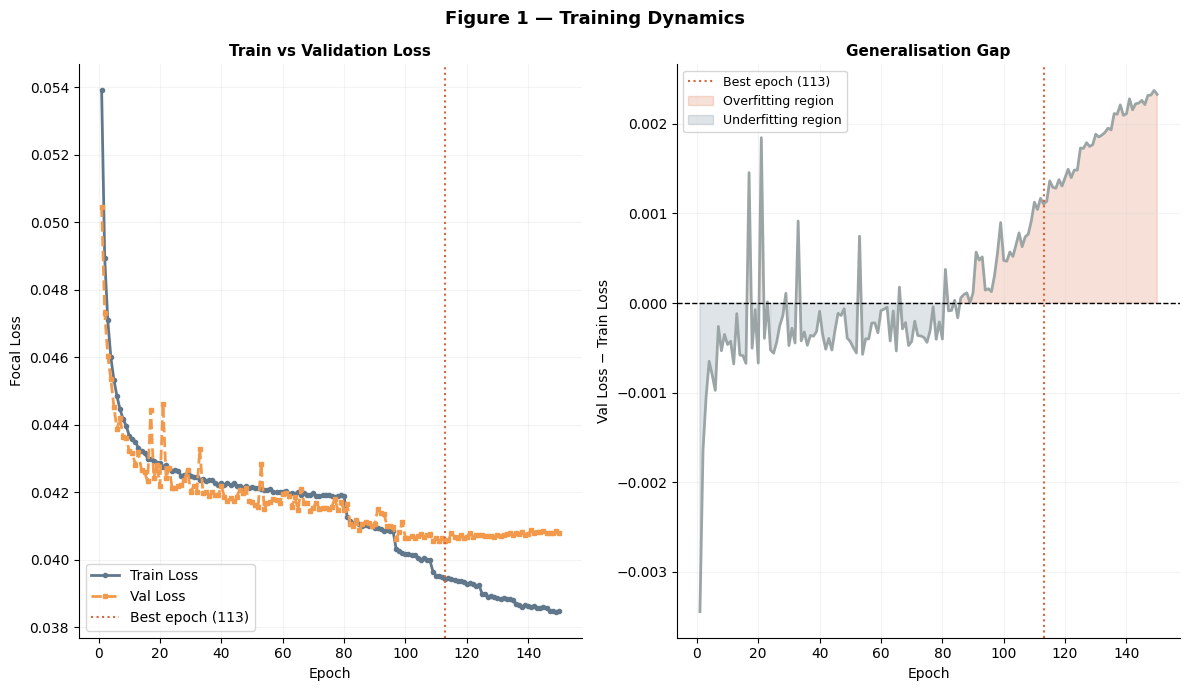

  Saved: eval_fig2_threshold_analysis.png


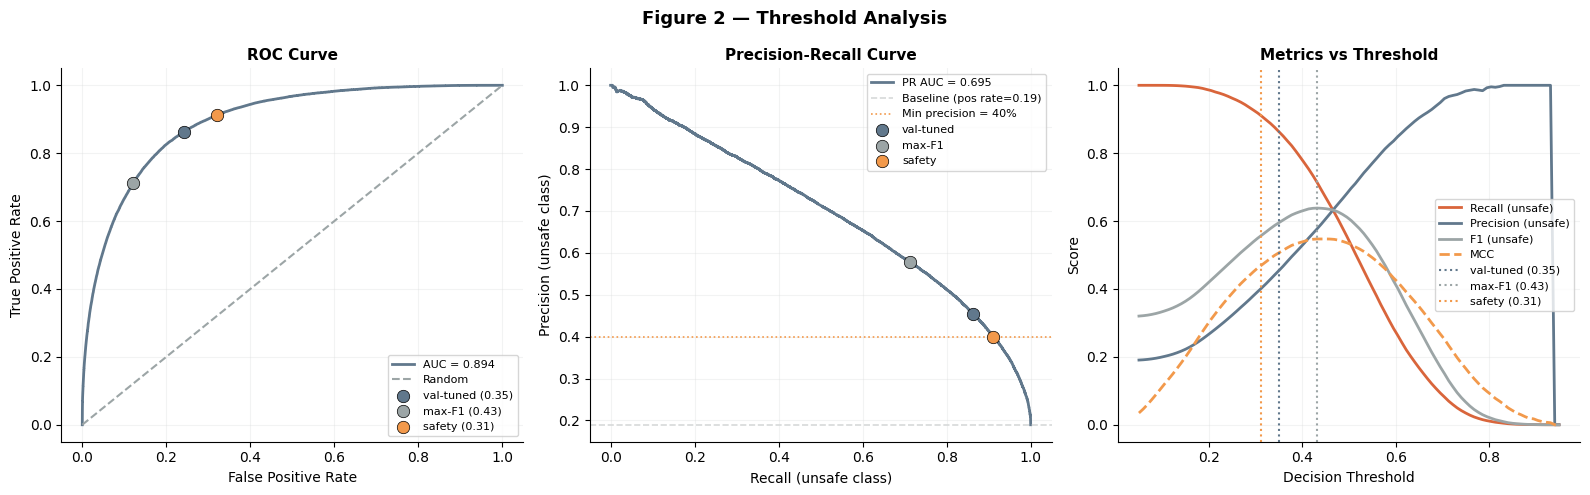

  Saved: eval_fig3_prediction_quality.png


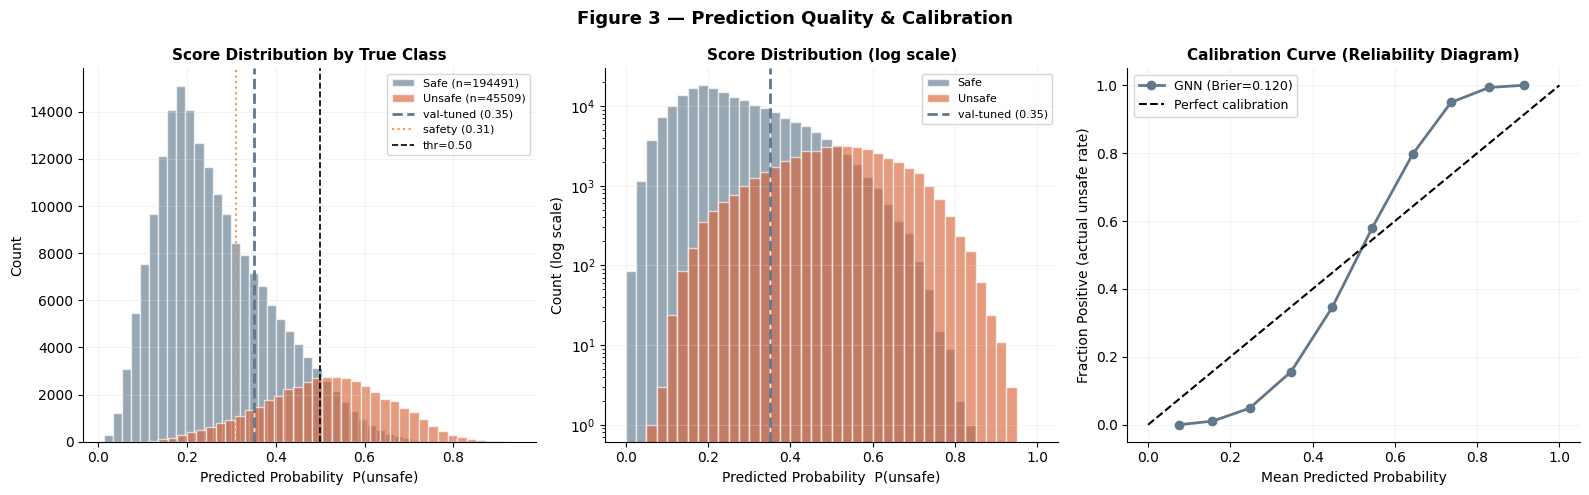

  Saved: eval_fig4_confusion_matrices.png


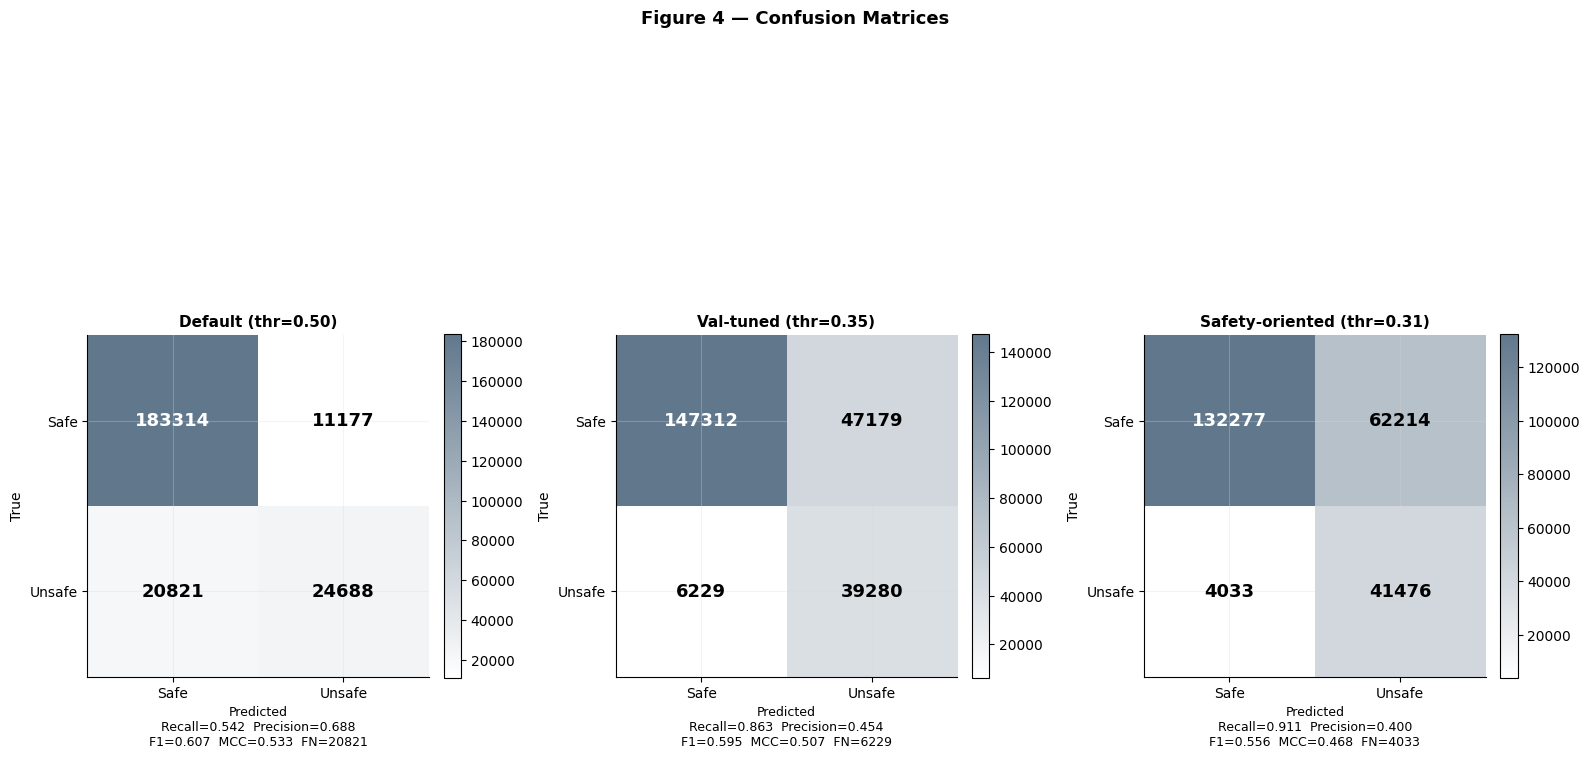

  Saved: eval_fig5_per_member.png


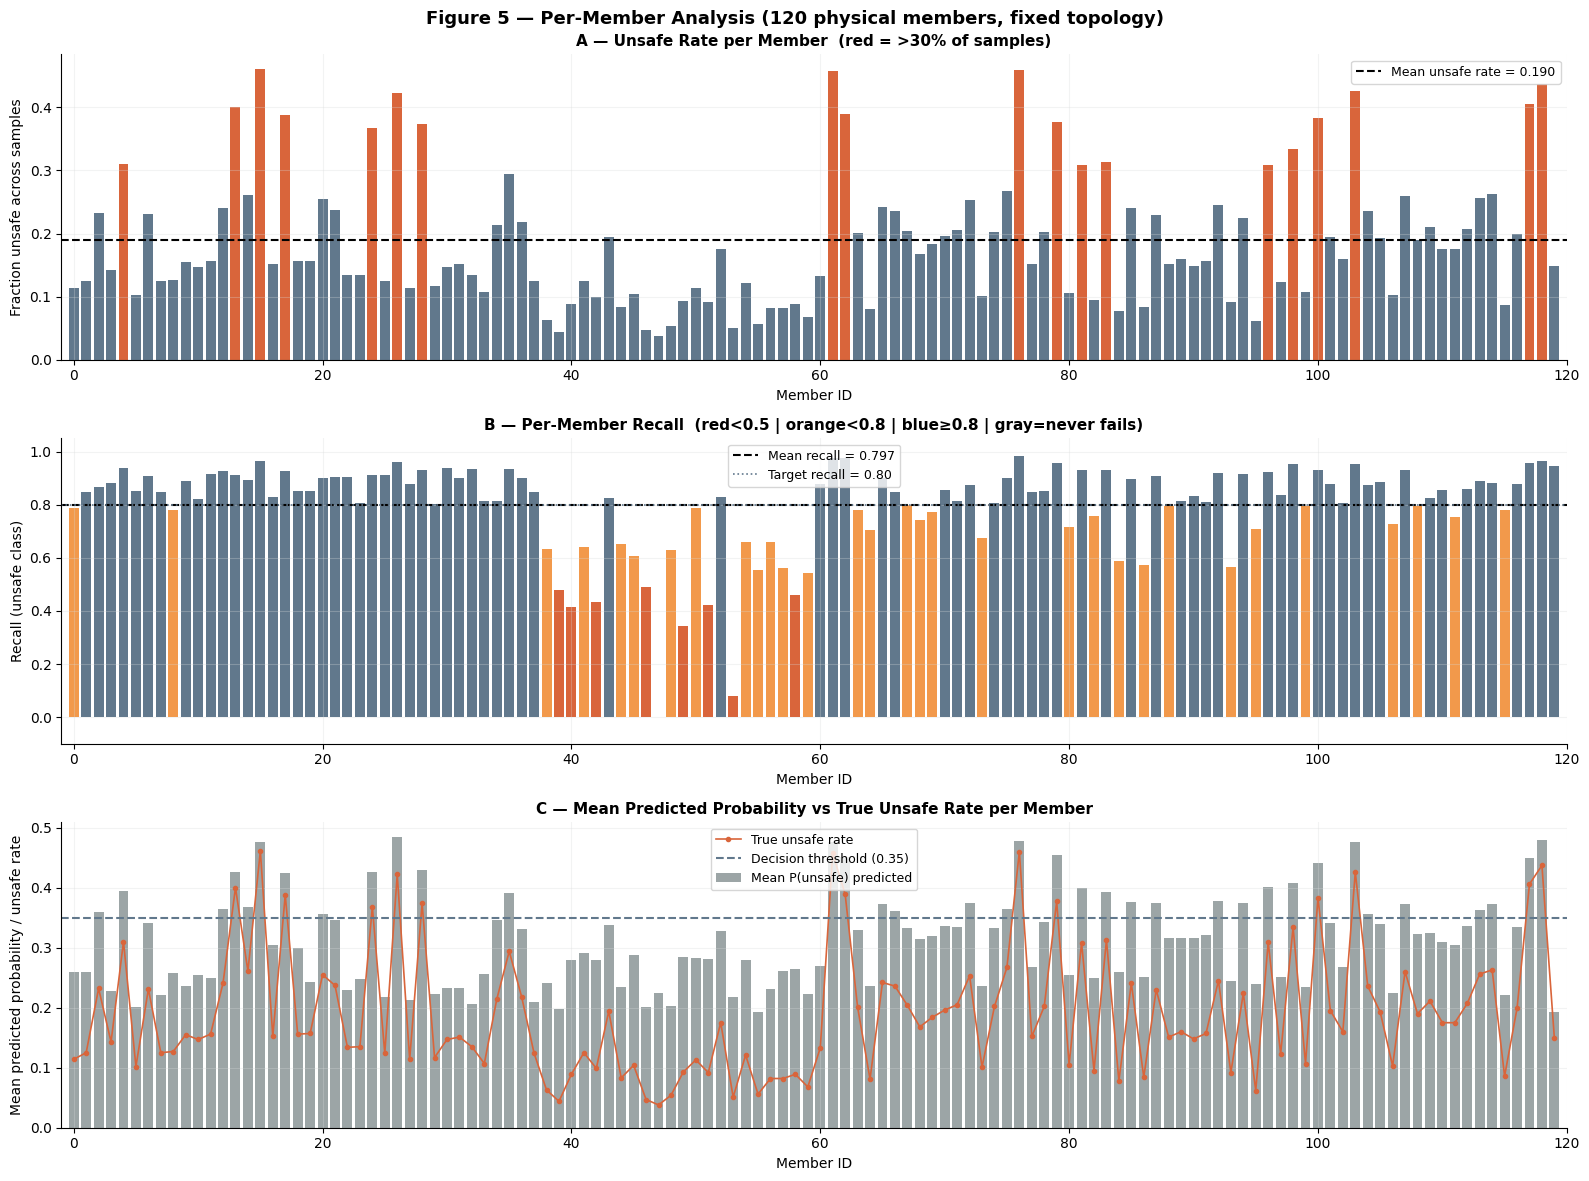


Top 10 hardest members (lowest recall, physical members 0-119):
  MemberID  UnsafeRate    Recall       FPR
        47       0.038     0.000     0.002
        53       0.051     0.078     0.007
        49       0.093     0.344     0.149
        40       0.089     0.416     0.147
        51       0.092     0.424     0.122
        42       0.099     0.434     0.156
        58       0.089     0.461     0.147
        39       0.044     0.477     0.058
        46       0.047     0.489     0.065
        59       0.068     0.544     0.101

EVALUATION SUMMARY — TrussEdgeSafetyGNN
  Epochs trained:      150  (best: 113)
  Final train loss:    0.038481
  Final val loss:      0.040810

  Threshold-independent:
    ROC AUC:    0.8939   (>0.90 = excellent, >0.80 = good)
    PR  AUC:    0.6946   (baseline = 0.190)
    Brier:      0.1195   (0 = perfect calibration)

  @ Default (thr=0.50):
    Accuracy:        0.8667
    Precision:       0.6884
    Recall (unsafe): 0.5425   <- most important for stru

In [3]:
# =============================================================================
# Binary Classification Evaluation — TrussEdgeSafetyGNN
# =============================================================================
#
# Requires from training:
#   train_losses, val_losses      — per-epoch loss lists
#   test_probs, test_targets      — flat numpy arrays from collect_preds()
#   best_threshold                — threshold chosen on val set (from train script)
#   best_epoch                    — epoch at which best checkpoint was saved
#
# Produces:
#   fig1  — Training dynamics  (loss curves + generalisation gap)
#   fig2  — Threshold analysis (ROC, PR, metrics vs threshold sweep)
#   fig3  — Prediction quality (probability distributions + calibration)
#   fig4  — Confusion matrices (default | val-tuned | safety threshold)
#   fig5  — Per-member analysis (unsafe rate, recall, mean prob — 120 physical members)
#   metrics — dict of all scalar metrics for export cell
#
# Fixes vs v3:
#   - Per-member slicing moved to AFTER computation (was before, causing NameError)
#   - NUM_EDGES_PHYSICAL = 120 used for per-member plots (was 240, showing duplicates)
#   - NUM_EDGES = 240 retained for test set reshaping (bidirectional)
#   - save_fig routes to config.SM_EXPORT_PATH

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (
    accuracy_score, auc, brier_score_loss, confusion_matrix,
    f1_score, matthews_corrcoef, precision_recall_curve,
    precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.calibration import calibration_curve
import config
from config import PLOT_COLORS as C, PLOT_STYLE as S

# =============================================================================
# 0. SETTINGS
# =============================================================================

NUM_EDGES          = 240   # total edges per sample after bidirectional conversion
NUM_EDGES_PHYSICAL = 120   # physical members — first half of bidirectional edge list
MIN_PRECISION      = 0.40  # minimum precision for safety-oriented threshold
SAVE_PATH          = config.SM_EXPORT_PATH

# =============================================================================
# 1. GUARD
# =============================================================================

required_vars = [
    "train_losses", "val_losses",
    "test_probs", "test_targets",
    "best_threshold", "best_epoch",
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        "Missing variables from training script: "
        + ", ".join(missing)
        + ". Run c21_train_v2.py first."
    )

# =============================================================================
# 2. GLOBAL STYLE
# =============================================================================

plt.rcParams.update({
    "figure.dpi":        S["dpi"],
    "axes.grid":         True,
    "grid.alpha":        S["grid_alpha"],
    "grid.color":        C["neutral"],
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.edgecolor":    C["black"],
    "axes.labelcolor":   C["black"],
    "xtick.color":       C["black"],
    "ytick.color":       C["black"],
    "text.color":        C["black"],
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
    "lines.linewidth":   S["line_width"],
    "lines.markersize":  S["marker_size"],
})

def save_fig(fig, stem):
    out = SAVE_PATH / f"{stem}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight", facecolor=C["white"])
    print(f"  Saved: {out.name}")

# =============================================================================
# 3. CORE METRICS
# =============================================================================

test_probs_arr = np.asarray(test_probs).flatten()
test_true      = np.asarray(test_targets).flatten().astype(int)
epochs_range   = np.arange(1, len(train_losses) + 1)

# Curves
fpr, tpr, _                           = roc_curve(test_true, test_probs_arr)
roc_auc                               = roc_auc_score(test_true, test_probs_arr)
precision_curve, recall_curve, pr_thr = precision_recall_curve(test_true, test_probs_arr)
pr_auc                                = auc(recall_curve, precision_curve)

# Threshold A: maximise F1
f1_curve     = (2 * precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-12)
idx_f1       = int(np.argmax(f1_curve[:-1]))
threshold_f1 = float(pr_thr[idx_f1]) if len(pr_thr) > 0 else 0.5

# Threshold B: maximise recall subject to precision >= MIN_PRECISION
viable_mask = precision_curve[:-1] >= MIN_PRECISION
if viable_mask.any():
    idx_safety       = np.where(viable_mask)[0][int(np.argmax(recall_curve[:-1][viable_mask]))]
    threshold_safety = float(pr_thr[idx_safety])
else:
    threshold_safety = threshold_f1
    print(f"Warning: no threshold achieves precision >= {MIN_PRECISION:.0%}; "
          f"falling back to max-F1 threshold ({threshold_f1:.3f}).")

thr_primary = float(best_threshold)

def scores_at(thr):
    pred               = (test_probs_arr >= thr).astype(int)
    cm                 = confusion_matrix(test_true, pred, labels=[0, 1])
    tn_, fp_, fn_, tp_ = cm.ravel()
    return dict(
        threshold=thr, pred=pred, cm=cm,
        tn=int(tn_), fp=int(fp_), fn=int(fn_), tp=int(tp_),
        accuracy  = accuracy_score(test_true, pred),
        precision = precision_score(test_true, pred, zero_division=0),
        recall    = recall_score(test_true, pred, zero_division=0),
        f1        = f1_score(test_true, pred, zero_division=0),
        mcc       = matthews_corrcoef(test_true, pred),
    )

s_05      = scores_at(0.5)
s_primary = scores_at(thr_primary)
s_f1      = scores_at(threshold_f1)
s_safety  = scores_at(threshold_safety)
brier     = brier_score_loss(test_true, test_probs_arr)

print(f"Thresholds — val-tuned: {thr_primary:.3f} | max-F1: {threshold_f1:.3f} | "
      f"safety (P>={MIN_PRECISION:.0%}): {threshold_safety:.3f}")

# =============================================================================
# 4. FIGURE 1 — Training Dynamics
# =============================================================================

fig1, axes = plt.subplots(1, 2, figsize=S["figsize_medium"])
fig1.suptitle("Figure 1 — Training Dynamics", fontweight="bold", fontsize=13)

ax = axes[0]
ax.plot(epochs_range, train_losses, color=C["primary"],
        lw=S["line_width"], marker="o", ms=3, label="Train Loss")
ax.plot(epochs_range, val_losses,   color=C["accent"],
        lw=S["line_width"], marker="s", ms=3, linestyle="--", label="Val Loss")
ax.axvline(best_epoch + 1, color=C["danger"], linestyle=":", lw=1.5,
           label=f"Best epoch ({best_epoch + 1})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Focal Loss")
ax.set_title("Train vs Validation Loss")
ax.legend()

ax = axes[1]
gap = np.array(val_losses) - np.array(train_losses)
ax.plot(epochs_range, gap, color=C["secondary"], lw=S["line_width"])
ax.axhline(0, color=C["black"], linestyle="--", lw=1)
ax.axvline(best_epoch + 1, color=C["danger"], linestyle=":", lw=1.5,
           label=f"Best epoch ({best_epoch + 1})")
ax.fill_between(epochs_range, gap, 0, where=(gap > 0),
                alpha=0.2, color=C["danger"],  label="Overfitting region")
ax.fill_between(epochs_range, gap, 0, where=(gap < 0),
                alpha=0.2, color=C["primary"], label="Underfitting region")
ax.set_xlabel("Epoch")
ax.set_ylabel("Val Loss − Train Loss")
ax.set_title("Generalisation Gap")
ax.legend(fontsize=9)

plt.tight_layout()
save_fig(fig1, "eval_fig1_training_dynamics")
plt.show()

# =============================================================================
# 5. FIGURE 2 — Threshold Analysis
# =============================================================================

fig2, axes = plt.subplots(1, 3, figsize=(S["figsize_large"][0], 5))
fig2.suptitle("Figure 2 — Threshold Analysis", fontweight="bold", fontsize=13)

ax = axes[0]
ax.plot(fpr, tpr, color=C["primary"], lw=S["line_width"], label=f"AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], color=C["secondary"], lw=1.5, linestyle="--", label="Random")
for s, label, col in [
    (s_primary, f"val-tuned ({thr_primary:.2f})",   C["primary"]),
    (s_f1,      f"max-F1 ({threshold_f1:.2f})",     C["secondary"]),
    (s_safety,  f"safety ({threshold_safety:.2f})", C["accent"]),
]:
    ax.scatter(s["fp"] / max(s["fp"] + s["tn"], 1),
               s["tp"] / max(s["tp"] + s["fn"], 1),
               color=col, zorder=5, s=80, label=label,
               edgecolors=C["black"], linewidths=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend(fontsize=8, loc="lower right")

ax = axes[1]
ax.plot(recall_curve, precision_curve, color=C["primary"],
        lw=S["line_width"], label=f"PR AUC = {pr_auc:.3f}")
baseline = test_true.mean()
ax.axhline(baseline, color=C["neutral"], linestyle="--", lw=1.2,
           label=f"Baseline (pos rate={baseline:.2f})")
ax.axhline(MIN_PRECISION, color=C["accent"], linestyle=":", lw=1.2,
           label=f"Min precision = {MIN_PRECISION:.0%}")
for s, label, col in [
    (s_primary, "val-tuned", C["primary"]),
    (s_f1,      "max-F1",    C["secondary"]),
    (s_safety,  "safety",    C["accent"]),
]:
    ax.scatter(s["recall"], s["precision"], color=col, zorder=5, s=80,
               label=label, edgecolors=C["black"], linewidths=0.5)
ax.set_xlabel("Recall (unsafe class)")
ax.set_ylabel("Precision (unsafe class)")
ax.set_title("Precision-Recall Curve")
ax.legend(fontsize=8)

ax = axes[2]
sweep_thresholds                              = np.linspace(0.05, 0.95, 100)
sweep_recall, sweep_precision, sweep_f1, sweep_mcc = [], [], [], []
for t in sweep_thresholds:
    pred = (test_probs_arr >= t).astype(int)
    sweep_recall.append(recall_score(test_true, pred, zero_division=0))
    sweep_precision.append(precision_score(test_true, pred, zero_division=0))
    sweep_f1.append(f1_score(test_true, pred, zero_division=0))
    sweep_mcc.append(matthews_corrcoef(test_true, pred))

ax.plot(sweep_thresholds, sweep_recall,    color=C["danger"],    lw=S["line_width"], label="Recall (unsafe)")
ax.plot(sweep_thresholds, sweep_precision, color=C["primary"],   lw=S["line_width"], label="Precision (unsafe)")
ax.plot(sweep_thresholds, sweep_f1,        color=C["secondary"], lw=S["line_width"], label="F1 (unsafe)")
ax.plot(sweep_thresholds, sweep_mcc,       color=C["accent"],    lw=S["line_width"], linestyle="--", label="MCC")
ax.axvline(thr_primary,      color=C["primary"],   lw=1.5, linestyle=":", label=f"val-tuned ({thr_primary:.2f})")
ax.axvline(threshold_f1,     color=C["secondary"], lw=1.5, linestyle=":", label=f"max-F1 ({threshold_f1:.2f})")
ax.axvline(threshold_safety, color=C["accent"],    lw=1.5, linestyle=":", label=f"safety ({threshold_safety:.2f})")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Metrics vs Threshold")
ax.legend(fontsize=8)

plt.tight_layout()
save_fig(fig2, "eval_fig2_threshold_analysis")
plt.show()

# =============================================================================
# 6. FIGURE 3 — Prediction Quality & Calibration
# =============================================================================

fig3, axes = plt.subplots(1, 3, figsize=(S["figsize_large"][0], 5))
fig3.suptitle("Figure 3 — Prediction Quality & Calibration", fontweight="bold", fontsize=13)

ax = axes[0]
ax.hist(test_probs_arr[test_true == 0], bins=40, alpha=0.65,
        label=f"Safe (n={int((test_true==0).sum())})",
        color=C["primary"], edgecolor=C["white"])
ax.hist(test_probs_arr[test_true == 1], bins=40, alpha=0.65,
        label=f"Unsafe (n={int((test_true==1).sum())})",
        color=C["danger"], edgecolor=C["white"])
ax.axvline(thr_primary,      color=C["primary"], lw=2,   linestyle="--", label=f"val-tuned ({thr_primary:.2f})")
ax.axvline(threshold_safety, color=C["accent"],  lw=1.5, linestyle=":",  label=f"safety ({threshold_safety:.2f})")
ax.axvline(0.5,              color=C["black"],   lw=1.2, linestyle="--", label="thr=0.50")
ax.set_xlabel("Predicted Probability  P(unsafe)")
ax.set_ylabel("Count")
ax.set_title("Score Distribution by True Class")
ax.legend(fontsize=8)

ax = axes[1]
bins = np.linspace(0, 1, 41)
ax.hist(test_probs_arr[test_true == 0], bins=bins, alpha=0.65,
        label="Safe",   color=C["primary"], edgecolor=C["white"])
ax.hist(test_probs_arr[test_true == 1], bins=bins, alpha=0.65,
        label="Unsafe", color=C["danger"],  edgecolor=C["white"])
ax.axvline(thr_primary, color=C["primary"], lw=2, linestyle="--",
           label=f"val-tuned ({thr_primary:.2f})")
ax.set_yscale("log")
ax.set_xlabel("Predicted Probability  P(unsafe)")
ax.set_ylabel("Count (log scale)")
ax.set_title("Score Distribution (log scale)")
ax.legend(fontsize=8)

ax = axes[2]
try:
    frac_pos, mean_pred = calibration_curve(
        test_true, test_probs_arr, n_bins=10, strategy="uniform"
    )
    ax.plot(mean_pred, frac_pos, color=C["primary"],
            lw=S["line_width"], marker="o", ms=6, label=f"GNN (Brier={brier:.3f})")
except Exception as e:
    ax.text(0.5, 0.5, f"Calibration n/a\n({e})", ha="center", va="center", fontsize=9)
ax.plot([0, 1], [0, 1], color=C["black"], linestyle="--", lw=1.5,
        label="Perfect calibration")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction Positive (actual unsafe rate)")
ax.set_title("Calibration Curve (Reliability Diagram)")
ax.legend(fontsize=9)

plt.tight_layout()
save_fig(fig3, "eval_fig3_prediction_quality")
plt.show()

# =============================================================================
# 7. FIGURE 4 — Confusion Matrices
# =============================================================================

fig4, axes = plt.subplots(1, 3, figsize=S["figsize_large"])
fig4.suptitle("Figure 4 — Confusion Matrices", fontweight="bold", fontsize=13)

cm_cmap = LinearSegmentedColormap.from_list("cm", [C["white"], C["primary"]], N=256)

for ax, (s, title) in zip(axes, [
    (s_05,      "Default (thr=0.50)"),
    (s_primary, f"Val-tuned (thr={thr_primary:.2f})"),
    (s_safety,  f"Safety-oriented (thr={threshold_safety:.2f})"),
]):
    cm = s["cm"]
    im = ax.imshow(cm, interpolation="nearest", cmap=cm_cmap)
    ax.set_title(title)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Safe", "Unsafe"])
    ax.set_yticklabels(["Safe", "Unsafe"])
    for i in range(2):
        for j in range(2):
            val   = cm[i, j]
            color = C["white"] if val > cm.max() * 0.6 else C["black"]
            ax.text(j, i, f"{val}", ha="center", va="center",
                    fontsize=13, fontweight="bold", color=color)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xlabel(
        f"Predicted\n"
        f"Recall={s['recall']:.3f}  Precision={s['precision']:.3f}\n"
        f"F1={s['f1']:.3f}  MCC={s['mcc']:.3f}  FN={s['fn']}",
        fontsize=9,
    )
    ax.set_ylabel("True")

plt.tight_layout()
save_fig(fig4, "eval_fig4_confusion_matrices")
plt.show()

# =============================================================================
# 8. FIGURE 5 — Per-Member Analysis
# Reshape test predictions to [n_samples, NUM_EDGES], then slice to first
# NUM_EDGES_PHYSICAL columns — the second half are reverse-edge duplicates
# with identical statistics and don't add information.
# =============================================================================

fig5                   = None
per_member_recall      = None
per_member_fpr         = None
per_member_unsafe_rate = None

n_test_samples = len(test_probs_arr) // NUM_EDGES

if len(test_probs_arr) % NUM_EDGES == 0 and n_test_samples > 0:

    # Reshape to [n_samples, 240] then slice to [n_samples, 120]
    preds_mat   = (test_probs_arr >= thr_primary).astype(int).reshape(n_test_samples, NUM_EDGES)
    targets_mat = test_true.reshape(n_test_samples, NUM_EDGES)
    probs_mat   = test_probs_arr.reshape(n_test_samples, NUM_EDGES)

    # Slice to physical members only — reverse edges are statistical duplicates
    preds_mat   = preds_mat[:, :NUM_EDGES_PHYSICAL]
    targets_mat = targets_mat[:, :NUM_EDGES_PHYSICAL]
    probs_mat   = probs_mat[:, :NUM_EDGES_PHYSICAL]

    # Per-member statistics (now over 120 physical members)
    per_member_unsafe_rate = targets_mat.mean(axis=0)
    per_member_recall      = np.where(
        targets_mat.sum(axis=0) > 0,
        ((preds_mat == 1) & (targets_mat == 1)).sum(axis=0) / targets_mat.sum(axis=0).clip(1),
        np.nan,
    )
    per_member_fpr = np.where(
        (1 - targets_mat).sum(axis=0) > 0,
        ((preds_mat == 1) & (targets_mat == 0)).sum(axis=0) / (1 - targets_mat).sum(axis=0).clip(1),
        np.nan,
    )
    per_member_mean_prob = probs_mat.mean(axis=0)
    edge_ids = np.arange(NUM_EDGES_PHYSICAL)

    fig5, axes = plt.subplots(3, 1, figsize=(S["figsize_large"][0], 12))
    fig5.suptitle(
        f"Figure 5 — Per-Member Analysis ({NUM_EDGES_PHYSICAL} physical members, fixed topology)",
        fontweight="bold", fontsize=13,
    )

    # A: unsafe rate per member
    ax = axes[0]
    colors_rate = [C["danger"] if r > 0.3 else C["primary"] for r in per_member_unsafe_rate]
    ax.bar(edge_ids, per_member_unsafe_rate, color=colors_rate, edgecolor="none", width=0.8)
    ax.axhline(per_member_unsafe_rate.mean(), color=C["black"], linestyle="--", lw=1.5,
               label=f"Mean unsafe rate = {per_member_unsafe_rate.mean():.3f}")
    ax.set_xlabel("Member ID")
    ax.set_ylabel("Fraction unsafe across samples")
    ax.set_title("A — Unsafe Rate per Member  (red = >30% of samples)")
    ax.legend(fontsize=9)
    ax.set_xlim(-1, NUM_EDGES_PHYSICAL)

    # B: recall per member
    ax = axes[1]
    recall_vals   = np.nan_to_num(per_member_recall, nan=-0.05)
    colors_recall = []
    for r, rate in zip(recall_vals, per_member_unsafe_rate):
        if rate == 0:
            colors_recall.append(C["neutral"])
        elif r < 0.5:
            colors_recall.append(C["danger"])
        elif r < 0.8:
            colors_recall.append(C["accent"])
        else:
            colors_recall.append(C["primary"])
    ax.bar(edge_ids, recall_vals, color=colors_recall, edgecolor="none", width=0.8)
    ax.axhline(np.nanmean(per_member_recall), color=C["black"], linestyle="--", lw=1.5,
               label=f"Mean recall = {np.nanmean(per_member_recall):.3f}")
    ax.axhline(0.8, color=C["primary"], linestyle=":", lw=1.2, label="Target recall = 0.80")
    ax.set_xlabel("Member ID")
    ax.set_ylabel("Recall (unsafe class)")
    ax.set_title("B — Per-Member Recall  (red<0.5 | orange<0.8 | blue≥0.8 | gray=never fails)")
    ax.set_ylim(-0.1, 1.05)
    ax.set_xlim(-1, NUM_EDGES_PHYSICAL)
    ax.legend(fontsize=9)

    # C: mean predicted probability vs true unsafe rate
    ax = axes[2]
    ax.bar(edge_ids, per_member_mean_prob, color=C["secondary"],
           edgecolor="none", width=0.8, label="Mean P(unsafe) predicted")
    ax.plot(edge_ids, per_member_unsafe_rate, color=C["danger"],
            marker="o", ms=3, lw=1.2, label="True unsafe rate")
    ax.axhline(thr_primary, color=C["primary"], linestyle="--", lw=1.5,
               label=f"Decision threshold ({thr_primary:.2f})")
    ax.set_xlabel("Member ID")
    ax.set_ylabel("Mean predicted probability / unsafe rate")
    ax.set_title("C — Mean Predicted Probability vs True Unsafe Rate per Member")
    ax.set_xlim(-1, NUM_EDGES_PHYSICAL)
    ax.legend(fontsize=9)

    plt.tight_layout()
    save_fig(fig5, "eval_fig5_per_member")
    plt.show()

    # Top 10 hardest members
    members_that_fail = np.where(per_member_unsafe_rate > 0)[0]
    sorted_by_recall  = members_that_fail[np.argsort(per_member_recall[members_that_fail])]
    print(f"\nTop 10 hardest members (lowest recall, physical members 0-{NUM_EDGES_PHYSICAL-1}):")
    print(f"  {'MemberID':>8}  {'UnsafeRate':>10}  {'Recall':>8}  {'FPR':>8}")
    for mid in sorted_by_recall[:10]:
        print(f"  {mid:>8d}  {per_member_unsafe_rate[mid]:>10.3f}  "
              f"{per_member_recall[mid]:>8.3f}  {per_member_fpr[mid]:>8.3f}")

else:
    print(f"\n[Per-member analysis skipped] "
          f"len(test_probs_arr)={len(test_probs_arr)} is not divisible by "
          f"NUM_EDGES={NUM_EDGES}.")

# =============================================================================
# 9. METRICS SUMMARY
# =============================================================================

print("\n" + "=" * 65)
print("EVALUATION SUMMARY — TrussEdgeSafetyGNN")
print("=" * 65)
print(f"  Epochs trained:      {len(train_losses)}  (best: {best_epoch + 1})")
print(f"  Final train loss:    {train_losses[-1]:.6f}")
print(f"  Final val loss:      {val_losses[-1]:.6f}")
print()
print("  Threshold-independent:")
print(f"    ROC AUC:    {roc_auc:.4f}   (>0.90 = excellent, >0.80 = good)")
print(f"    PR  AUC:    {pr_auc:.4f}   (baseline = {test_true.mean():.3f})")
print(f"    Brier:      {brier:.4f}   (0 = perfect calibration)")
print()
for label, s in [
    ("Default (thr=0.50)",                  s_05),
    (f"Val-tuned  (thr={thr_primary:.2f})", s_primary),
    (f"Safety     (thr={threshold_safety:.2f})", s_safety),
]:
    print(f"  @ {label}:")
    print(f"    Accuracy:        {s['accuracy']:.4f}")
    print(f"    Precision:       {s['precision']:.4f}")
    print(f"    Recall (unsafe): {s['recall']:.4f}   <- most important for structural safety")
    print(f"    F1:              {s['f1']:.4f}")
    print(f"    MCC:             {s['mcc']:.4f}   (>0.5 = good for imbalanced data)")
    print(f"    TP={s['tp']}  TN={s['tn']}  FP={s['fp']}  FN={s['fn']}  (FN = missed failures)")
    print()
print("=" * 65)

# =============================================================================
# 10. METRICS DICT
# =============================================================================

metrics = {
    "roc_auc":              float(roc_auc),
    "pr_auc":               float(pr_auc),
    "brier_score":          float(brier),
    "acc_0.50":             float(s_05["accuracy"]),
    "precision_0.50":       float(s_05["precision"]),
    "recall_0.50":          float(s_05["recall"]),
    "f1_0.50":              float(s_05["f1"]),
    "mcc_0.50":             float(s_05["mcc"]),
    "threshold_primary":    float(thr_primary),
    "acc_primary":          float(s_primary["accuracy"]),
    "precision_primary":    float(s_primary["precision"]),
    "recall_primary":       float(s_primary["recall"]),
    "f1_primary":           float(s_primary["f1"]),
    "mcc_primary":          float(s_primary["mcc"]),
    "tp_primary":           int(s_primary["tp"]),
    "tn_primary":           int(s_primary["tn"]),
    "fp_primary":           int(s_primary["fp"]),
    "fn_primary":           int(s_primary["fn"]),
    "threshold_safety":     float(threshold_safety),
    "acc_safety":           float(s_safety["accuracy"]),
    "precision_safety":     float(s_safety["precision"]),
    "recall_safety":        float(s_safety["recall"]),
    "f1_safety":            float(s_safety["f1"]),
    "mcc_safety":           float(s_safety["mcc"]),
    "tp_safety":            int(s_safety["tp"]),
    "tn_safety":            int(s_safety["tn"]),
    "fp_safety":            int(s_safety["fp"]),
    "fn_safety":            int(s_safety["fn"]),
    "false_negative_rate":  float(s_safety["fn"] / max(s_safety["tp"] + s_safety["fn"], 1)),
    "best_epoch":           int(best_epoch),
    "final_train_loss":     float(train_losses[-1]),
    "final_val_loss":       float(val_losses[-1]),
}

if per_member_recall is not None:
    metrics["per_member_recall_mean"] = float(np.nanmean(per_member_recall))
    metrics["per_member_recall_min"]  = float(np.nanmin(per_member_recall))
    metrics["per_member_fpr_mean"]    = float(np.nanmean(per_member_fpr))

print("\nEvaluation complete.")
print("Figures: fig1, fig2, fig3, fig4, fig5")
print("Metrics dict: metrics")

## Export

In [4]:
# --- Final evaluation export (follows c21_evaluation_v3.py) ---
#
# Requires from training:      model, loss_fn, focal_alpha, best_val_loss,
#                              best_epoch, train_losses, val_losses,
#                              LR, EPOCHS, PATIENCE, batch_size, CKPT_PATH
# Requires from preprocessing: node_cols, edge_cols, node_feature_means,
#                              node_feature_stds, edge_feature_means,
#                              edge_feature_stds, train_pos_rate,
#                              train_dataset, val_dataset, test_dataset,
#                              nodes_df, edges_df, node_csv_path,
#                              edge_csv_path, edge_index_path
# Requires from evaluation:    metrics, test_probs, test_true,
#                              thr_primary, threshold_f1, threshold_safety,
#                              roc_auc, pr_auc, brier,
#                              fig1, fig2, fig3, fig4, fig5
#
# Artifact folder structure:
#   SM_EXPORT_PATH / {stem} /   <- checkpoint, norm_stats, topology,
#                                  scalers, inference_config, report
#   SM_DATA_PATH   / {stem} /   <- metrics.json, figures, raw predictions

import json
import shutil
from datetime import datetime
from pathlib import Path

import numpy as np
import torch
import config

# ============================================================================
# GUARD
# ============================================================================

required = [
    # from preprocessing
    "node_cols", "edge_cols",
    "node_feature_means", "node_feature_stds",
    "edge_feature_means", "edge_feature_stds",
    "train_pos_rate", "train_dataset", "val_dataset", "test_dataset",
    "nodes_df", "edges_df", "node_csv_path", "edge_csv_path", "edge_index_path",
    "batch_size",
    # from training
    "model", "loss_fn", "focal_alpha", "best_val_loss", "best_epoch",
    "train_losses", "val_losses", "LR", "EPOCHS", "PATIENCE",
    "CKPT_PATH", "test_probs", "test_targets",
    # from evaluation
    "metrics", "test_true",
    "thr_primary", "threshold_f1", "threshold_safety",
    "roc_auc", "pr_auc", "brier",
]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(
        "Missing variables — run preprocessing, training, and evaluation cells first.\n"
        "Missing: " + ", ".join(missing)
    )

# ============================================================================
# ARTIFACT STEM
# ============================================================================

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
artifact_stem = (
    f"ID{ts}"
    f"_LR{LR:.0e}"
    f"_EP{len(train_losses)}"
    f"_BS{batch_size}"
    f"_FA{focal_alpha:.2f}"
    f"_ROC{roc_auc:.3f}"
)
print(f"Artifact stem: {artifact_stem}")

# ============================================================================
# DIRECTORIES
# ============================================================================

models_dir = config.SM_EXPORT_PATH / artifact_stem
data_dir   = config.SM_DATA_PATH   / artifact_stem
models_dir.mkdir(parents=True, exist_ok=True)
data_dir.mkdir(parents=True, exist_ok=True)

# ============================================================================
# 1. MODEL CHECKPOINT
# ============================================================================

ckpt_src    = Path(CKPT_PATH)
ckpt_target = models_dir / f"{artifact_stem}.pth"

if ckpt_src.exists():
    shutil.copy2(ckpt_src, ckpt_target)
    print(f"Checkpoint copied:   {ckpt_target.name}")
else:
    torch.save(
        {"model_state_dict": model.state_dict(),
         "best_val_loss": best_val_loss, "best_epoch": best_epoch},
        ckpt_target,
    )
    print(f"Warning: {CKPT_PATH} not found — saved current state to {ckpt_target.name}")

# ============================================================================
# 2. NORMALISATION STATS
# ============================================================================

norm_stats_src    = Path(config.DATA_IO_PATH) / "norm_stats.pt"
norm_stats_target = models_dir / f"{artifact_stem}_norm_stats.pt"

if norm_stats_src.exists():
    shutil.copy2(norm_stats_src, norm_stats_target)
    print(f"Norm stats copied:   {norm_stats_target.name}")
else:
    torch.save(
        {"node_means": node_feature_means.to_dict(),
         "node_stds":  node_feature_stds.to_dict(),
         "edge_means": edge_feature_means.to_dict(),
         "edge_stds":  edge_feature_stds.to_dict(),
         "node_cols":  list(node_cols),
         "edge_cols":  list(edge_cols)},
        norm_stats_target,
    )
    print(f"Norm stats rebuilt:  {norm_stats_target.name}")

# ============================================================================
# 3. TOPOLOGY
# ============================================================================

edge_index_target = models_dir / f"{artifact_stem}_edge_index.json"
shutil.copy2(edge_index_path, edge_index_target)
print(f"Topology copied:     {edge_index_target.name}")

# ============================================================================
# 4. SCALERS JSON (human-readable, for GH/Rhino inference)
# ============================================================================

scalers_path = models_dir / f"{artifact_stem}_scalers.json"
with open(scalers_path, "w") as f:
    json.dump({
        "node_cols":  list(node_cols),
        "edge_cols":  list(edge_cols),
        "node_mean":  node_feature_means.to_dict(),
        "node_std":   node_feature_stds.to_dict(),
        "edge_mean":  edge_feature_means.to_dict(),
        "edge_std":   edge_feature_stds.to_dict(),
    }, f, indent=2)
print(f"Scalers JSON saved:  {scalers_path.name}")

# ============================================================================
# 5. INFERENCE CONFIG
# ============================================================================

inference_config_path = models_dir / f"{artifact_stem}_inference_config.json"
with open(inference_config_path, "w") as f:
    json.dump({
        "model_class":           type(model).__name__,
        "node_features_dim":     len(node_cols),
        "edge_features_dim":     len(edge_cols),
        "hidden_dim":            getattr(model, "hidden_dim", "n/a"),
        "num_layers":            getattr(model, "num_layers", "n/a"),
        "use_batch_norm":        getattr(model, "use_batch_norm", "n/a"),
        "use_residuals":         getattr(model, "use_residuals", "n/a"),
        "dropout_p":             getattr(model, "dropout_p", "n/a"),
        "node_cols":             list(node_cols),
        "edge_cols":             list(edge_cols),
        "clip_sigma":            5.0,
        "threshold_primary":     float(thr_primary),
        "threshold_f1":          float(threshold_f1),
        "threshold_safety":      float(threshold_safety),
        "recommended_threshold": float(thr_primary),
        # output is P(unsafe) — predict unsafe if prob >= recommended_threshold
    }, f, indent=2)
print(f"Inference config:    {inference_config_path.name}")

# ============================================================================
# 6. METRICS JSON
# ============================================================================

metrics_path = data_dir / "metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"Metrics JSON saved:  {metrics_path.name}")

# ============================================================================
# 7. TRAINING REPORT
# ============================================================================

focal_gamma = float(getattr(loss_fn, "gamma", 2.0))
s_primary   = metrics  # shorthand for readability below

report_lines = [
    "SURROGATE MODEL TRAINING REPORT",
    "=" * 80,
    f"Artifact:      {artifact_stem}",
    f"Generated:     {ts}",
    "",
    "DATA SOURCES",
    "-" * 80,
    f"Node CSV:      {node_csv_path}",
    f"Edge CSV:      {edge_csv_path}",
    f"Edge index:    {edge_index_path}",
    f"Total samples: {len(train_dataset) + len(val_dataset) + len(test_dataset)}",
    f"Train/Val/Test:{len(train_dataset)} / {len(val_dataset)} / {len(test_dataset)}",
    f"Positive rate (train): {train_pos_rate:.4f}",
    f"Positive labels (full): {int((edges_df['Utilization'] > 1).sum())}",
    f"Negative labels (full): {int((edges_df['Utilization'] <= 1).sum())}",
    "",
    "MODEL CONFIGURATION",
    "-" * 80,
    f"Class:         {type(model).__name__}",
    f"Device:        {next(model.parameters()).device}",
    f"Hidden dim:    {getattr(model, 'hidden_dim', 'n/a')}",
    f"Num layers:    {getattr(model, 'num_layers', 'n/a')}",
    f"Batch norm:    {getattr(model, 'use_batch_norm', 'n/a')}",
    f"Residuals:     {getattr(model, 'use_residuals', 'n/a')}",
    f"Dropout p:     {getattr(model, 'dropout_p', 'n/a')}",
    f"Node features: {', '.join(node_cols)}",
    f"Edge features: {', '.join(edge_cols)}",
    "",
    "TRAINING HYPERPARAMETERS",
    "-" * 80,
    f"Learning rate:     {LR}",
    f"Max epochs:        {EPOCHS}",
    f"Early stop pat.:   {PATIENCE}",
    f"Actual epochs run: {len(train_losses)}",
    f"Best epoch:        {best_epoch + 1}",
    f"Batch size:        {batch_size}",
    f"Loss:              {type(loss_fn).__name__}",
    f"Focal alpha:       {focal_alpha:.6f}",
    f"Focal gamma:       {focal_gamma:.6f}",
    f"Best val loss:     {best_val_loss:.6f}",
    "",
    "EVALUATION SUMMARY",
    "-" * 80,
    f"ROC AUC:           {roc_auc:.6f}",
    f"PR  AUC:           {pr_auc:.6f}",
    f"Brier score:       {brier:.6f}",
    "",
    f"{'Metric':<22} {'thr=0.50':>10} {'val-tuned':>10} {'safety':>10}",
    "-" * 55,
    f"{'Accuracy':<22} {metrics['acc_0.50']:>10.4f} {metrics['acc_primary']:>10.4f} {metrics['acc_safety']:>10.4f}",
    f"{'Precision':<22} {metrics['precision_0.50']:>10.4f} {metrics['precision_primary']:>10.4f} {metrics['precision_safety']:>10.4f}",
    f"{'Recall (unsafe)':<22} {metrics['recall_0.50']:>10.4f} {metrics['recall_primary']:>10.4f} {metrics['recall_safety']:>10.4f}",
    f"{'F1':<22} {metrics['f1_0.50']:>10.4f} {metrics['f1_primary']:>10.4f} {metrics['f1_safety']:>10.4f}",
    f"{'MCC':<22} {metrics['mcc_0.50']:>10.4f} {metrics['mcc_primary']:>10.4f} {metrics['mcc_safety']:>10.4f}",
    "",
    f"Threshold (val-tuned):  {thr_primary:.4f}",
    f"Threshold (max-F1):     {threshold_f1:.4f}",
    f"Threshold (safety):     {threshold_safety:.4f}",
    f"False negative rate:    {metrics['false_negative_rate']:.4f}",
    f"TP={metrics['tp_safety']}  TN={metrics['tn_safety']}  "
    f"FP={metrics['fp_safety']}  FN={metrics['fn_safety']}",
    "",
    "FILES",
    "-" * 80,
    f"Checkpoint:       {ckpt_target.name}",
    f"Norm stats (.pt): {norm_stats_target.name}",
    f"Topology:         {edge_index_target.name}",
    f"Scalers JSON:     {scalers_path.name}",
    f"Inference config: {inference_config_path.name}",
    f"Metrics JSON:     {metrics_path.name}",
    "",
    "TRAINING HISTORY",
    "-" * 80,
    "Epoch,TrainLoss,ValLoss",
] + [f"{i},{tl:.10f},{vl:.10f}"
     for i, (tl, vl) in enumerate(zip(train_losses, val_losses), 1)]

report_path = models_dir / f"{artifact_stem}_training_report.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))
print(f"Training report:     {report_path.name}")

# ============================================================================
# 8. FIGURES  (fig1-fig5 from evaluation v3)
# ============================================================================

fig_map = {
    "fig1": "eval_fig1_training_dynamics",
    "fig2": "eval_fig2_threshold_analysis",
    "fig3": "eval_fig3_prediction_quality",
    "fig4": "eval_fig4_confusion_matrices",
    "fig5": "eval_fig5_per_member",
}
for var_name, stem in fig_map.items():
    fig = globals().get(var_name)
    if fig is not None:
        out = data_dir / f"{artifact_stem}_{stem}.png"
        fig.savefig(out, dpi=200, bbox_inches="tight")
        print(f"Figure saved:        {out.name}")
    else:
        print(f"Figure '{var_name}' not found — skipped.")

# ============================================================================
# 9. RAW PREDICTIONS + TARGETS
# ============================================================================

np.savetxt(data_dir / "test_probs.csv",   test_probs,   delimiter=",")
np.savetxt(data_dir / "test_targets.csv", test_targets, delimiter=",")
print("Raw predictions and targets saved.")

# ============================================================================
# SUMMARY
# ============================================================================

all_files = sorted(set(
    [ckpt_target, norm_stats_target, edge_index_target,
     scalers_path, inference_config_path, report_path, metrics_path]
    + list(data_dir.glob("*"))
))

print(f"\n{'='*65}")
print("EXPORT COMPLETE")
print(f"{'='*65}")
print(f"  Models dir: {models_dir}")
print(f"  Data dir:   {data_dir}")
print(f"\n  Files saved:")
for fp in all_files:
    size_kb = fp.stat().st_size / 1024
    print(f"    {fp.name:<58} {size_kb:6.1f} KB")

Artifact stem: ID20260512_193129_LR3e-04_EP150_BS32_FA0.50_ROC0.894
Checkpoint copied:   ID20260512_193129_LR3e-04_EP150_BS32_FA0.50_ROC0.894.pth
Norm stats copied:   ID20260512_193129_LR3e-04_EP150_BS32_FA0.50_ROC0.894_norm_stats.pt
Topology copied:     ID20260512_193129_LR3e-04_EP150_BS32_FA0.50_ROC0.894_edge_index.json
Scalers JSON saved:  ID20260512_193129_LR3e-04_EP150_BS32_FA0.50_ROC0.894_scalers.json
Inference config:    ID20260512_193129_LR3e-04_EP150_BS32_FA0.50_ROC0.894_inference_config.json
Metrics JSON saved:  metrics.json
Training report:     ID20260512_193129_LR3e-04_EP150_BS32_FA0.50_ROC0.894_training_report.txt
Figure saved:        ID20260512_193129_LR3e-04_EP150_BS32_FA0.50_ROC0.894_eval_fig1_training_dynamics.png
Figure saved:        ID20260512_193129_LR3e-04_EP150_BS32_FA0.50_ROC0.894_eval_fig2_threshold_analysis.png
Figure saved:        ID20260512_193129_LR3e-04_EP150_BS32_FA0.50_ROC0.894_eval_fig3_prediction_quality.png
Figure saved:        ID20260512_193129_LR3e-0